In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv(
    "../data/cleaned/sales_features.csv",
    parse_dates=["InvoiceDate"]
)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Quarter,Month,MonthName,Day,DayName,Week,Hour,Weekend
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,4,12,December,1,Tuesday,49,7,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,4,12,December,1,Tuesday,49,7,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,4,12,December,1,Tuesday,49,7,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,4,12,December,1,Tuesday,49,7,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,4,12,December,1,Tuesday,49,7,False


In [2]:
#Reference Date

snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(snapshot_date)

2010-12-10 20:01:00


In [3]:
#RFM Table

rfm = (
    df.groupby("Customer ID")
    .agg({
        "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
        "Invoice": "nunique",
        "Revenue":"sum"
    })
    .reset_index()
)

rfm.columns = [
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary"
]

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,222.16
3,12349.0,43,3,2671.14
4,12351.0,11,1,300.93


In [4]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000,4312.000000
mean,15349.290353,91.171846,4.455705,2040.406712
std,1701.200176,96.860633,8.170213,8911.755977
min,12346.000000,1.000000,1.000000,2.950000
25%,13882.500000,18.000000,1.000000,307.187500
50%,15350.500000,53.000000,2.000000,701.615000
75%,16834.250000,136.000000,5.000000,1714.932500
max,18287.000000,374.000000,205.000000,349164.350000


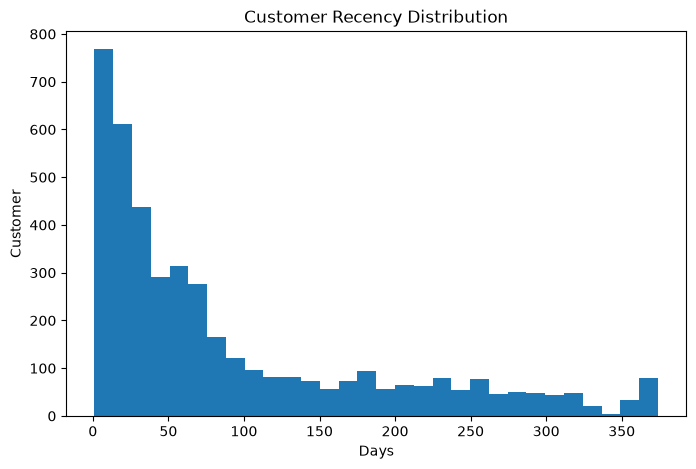

In [7]:
##Distribution Plot
#Recency
plt.figure(figsize=(8,5))

plt.hist(rfm["Recency"],bins=30)

plt.title("Customer Recency Distribution")
plt.xlabel("Days")
plt.ylabel("Customer")

plt.show()

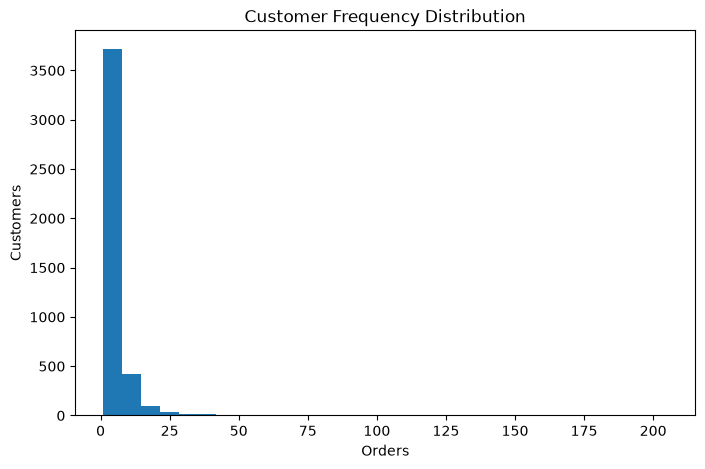

In [8]:
#Frequency
plt.figure(figsize=(8,5))

plt.hist(rfm["Frequency"],bins=30)
plt.title("Customer Frequency Distribution")
plt.xlabel("Orders")
plt.ylabel("Customers")
plt.show()

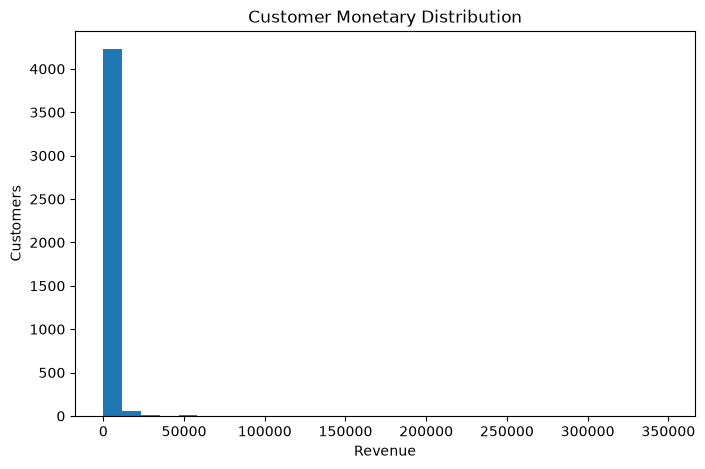

In [9]:
#Monetary
plt.figure(figsize=(8,5))

plt.hist(rfm["Monetary"],bins=30)

plt.title("Customer Monetary Distribution")
plt.xlabel("Revenue")
plt.ylabel("Customers")
plt.show()

In [10]:
#RFM Score
#Recency: lower is better
rfm["R"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

In [11]:
#Frequency:higher is better
rfm["F"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

In [12]:
#Monetary: higher is better
rfm["M"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

In [13]:
rfm["RFM_Score"] = (
    rfm["R"].astype(str) +
    rfm["F"].astype(str) +
    rfm["M"].astype(str)
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R,F,M,RFM_Score
0,12346.0,165,11,372.86,2,5,2,252
1,12347.0,3,2,1323.32,5,2,4,524
2,12348.0,74,1,222.16,2,1,1,211
3,12349.0,43,3,2671.14,3,3,5,335
4,12351.0,11,1,300.93,5,1,2,512


In [14]:
#Best Customers

best_customers = (
    rfm.sort_values(
        "Monetary",
        ascending=False
    )
    .head()
)
best_customers

,CustomerID,Recency,Frequency,Monetary,R,F,M,RFM_Score
4183,18102.0,1,89,349164.35,5,5,5,555
1637,14646.0,10,78,248396.50,5,5,5,555
1269,14156.0,7,102,196549.74,5,5,5,555
1840,14911.0,1,205,152121.22,5,5,5,555
939,13694.0,9,94,131443.19,5,5,5,555


In [15]:
#RFM Score Distribution

rfm["RFM_Score"].value_counts().head(20)

RFM_Score
555    349
111    202
455    153
121    144
112    105
444     97
233     97
122     96
554     95
344     93
544     92
211     89
244     76
333     76
355     75
221     73
212     70
311     69
312     67
443     65
Name: count, dtype: int64

In [16]:
rfm.to_csv(
    "../data/cleaned/customer_rfm.csv",
    index=False
)

print("RFM dataset saved successfully.")

RFM dataset saved successfully.
